In [14]:
# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [15]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('../source')

from initialdata.scalarcollapseinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *
from matter.nomatter import *

import matplotlib as mpl

rc = mpl.rcParams # Font structure is called rc now
rc['text.usetex'] = True # Tex fonts
rc['font.family'] = 'serif'
rc['font.size'] = 20
rc['xtick.labelsize'] = 15
rc['ytick.labelsize'] = 15
rc['lines.linewidth'] = 2
rc["axes.axisbelow"] = False
plt.rcParams['axes.formatter.min_exponent'] = 2
rc['axes.linewidth'] = 1.5


In [32]:
# Set up the chosen matter class
scalar_mu = 0
ampl = 1e-3
wid = 20
r0 = 150
Omega = 1
params_phi = [ampl, wid, r0, Omega]

# Input parameters for grid and evolution here
r_max = 400.0 # outer edge of the grid (including ghosts)
min_dr = 0.5 # 
max_dr = 2

# LinearSpacing
params = LinearSpacing.get_parameters(r_max, min_dr)
spacing = LinearSpacing(**params)

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
# params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = CubicSpacing(**params)

my_matter = NoMatter()
my_state_vector = StateVector(my_matter)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size

# Set up the chosen matter class
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# High resolution
min_dr_HR = 0.5 * min_dr
params_HR = LinearSpacing.get_parameters(r_max, min_dr_HR)
spacing_HR = LinearSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Low resolution
min_dr_LR = 2 * min_dr
params_LR = LinearSpacing.get_parameters(r_max, min_dr_LR)
spacing_LR = LinearSpacing(**params_LR)

grid_LR = Grid(spacing_LR, my_state_vector)
r_LR = grid_LR.r
num_points_LR = r_LR.size
background_LR = FlatSphericalBackground(r_LR)

# Check grid params
print(params)
print(params_HR)
print(params_LR)

{'r_max': 400.0, 'extent': <SpacingExtent.HALF: 0>, 'num_points': 804}
{'r_max': 400.0, 'extent': <SpacingExtent.HALF: 0>, 'num_points': 1604}
{'r_max': 400.0, 'extent': <SpacingExtent.HALF: 0>, 'num_points': 404}


In [33]:
initial_state = get_initial_state(grid, background, params_phi)
initial_state_HR = get_initial_state(grid_HR, background_HR, params_phi)
initial_state_LR = get_initial_state(grid_LR, background_LR, params_phi)

(-0.2, 400.0)

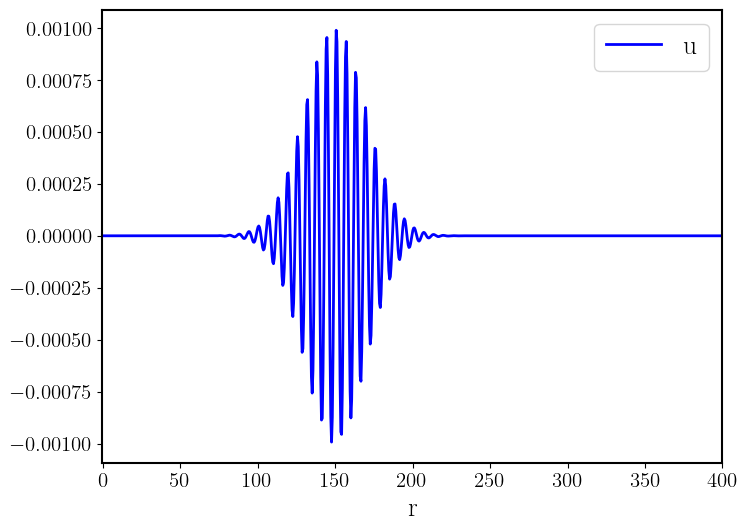

In [39]:
#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

(initial_phi_HR, initial_hrr_HR, initial_htt_HR, initial_hpp_HR, 
 initial_K_HR, initial_arr_HR, initial_att_HR, initial_app_HR, 
 initial_lambdar_HR, initial_shiftr_HR, initial_br_HR, initial_lapse_HR, 
 initial_u_HR, initial_v_HR) = np.array_split(initial_state_HR, grid_HR.NUM_VARS)

(initial_phi_LR, initial_hrr_LR, initial_htt_LR, initial_hpp_LR, 
 initial_K_LR, initial_arr_LR, initial_att_LR, initial_app_LR, 
 initial_lambdar_LR, initial_shiftr_LR, initial_br_LR, initial_lapse_LR, 
 initial_u_LR, initial_v_LR) = np.array_split(initial_state_LR, grid_LR.NUM_VARS)

fig = plt.figure(figsize=(8,6),dpi=100)

#plot initial conditions
plt.xlabel('r')
# plt.plot(r, np.exp(-4*initial_phi), c="k", label='phi')
plt.plot(r, initial_u, c="b", label='u')

plt.legend(loc='best')
# set_grid_on_ax(ax, r)
plt.xlim(-0.2,r[-1])
#plt.ylim(-0.001,0.001)

In [36]:
# check the Hamiltonian and momentum constraints are initially satisfied
Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter)
Ham_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)
Ham_LR, Mom_LR = get_constraints_diagnostic(initial_state_LR, np.array([0]), grid_LR, background_LR, my_matter)

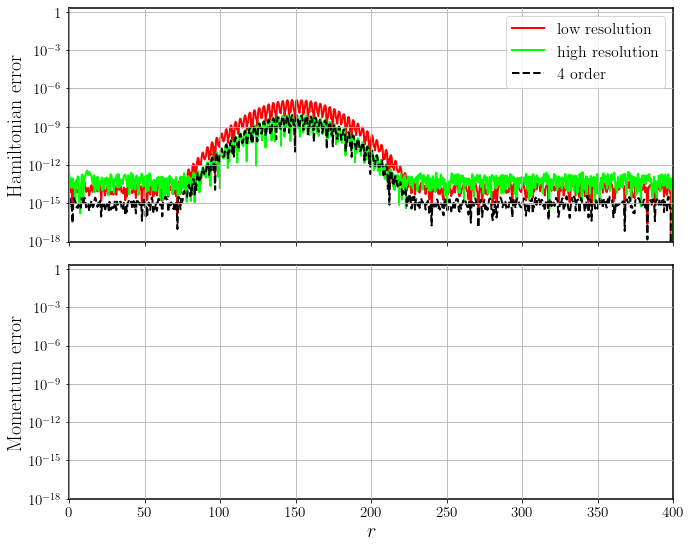

In [38]:
# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

order = 4
fig = plt.figure(figsize=(10,8))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212)
# # plot the profile for Ham
ax1.plot(r[NUM_GHOSTS:], abs(Ham[0][NUM_GHOSTS:]), '-', c="r", label=r"low resolution")
ax1.plot(r_HR[NUM_GHOSTS:], abs(Ham_HR[0][NUM_GHOSTS:]), '-', c="lime", label=r"high resolution")
ax1.plot(r[NUM_GHOSTS:], abs(Ham[0][NUM_GHOSTS:])/2**order, '--', c="k", label=str(order)+r" order")

ax2.plot(r[NUM_GHOSTS:], abs(Mom[0][NUM_GHOSTS:]), '-', c="r", label=r"Mom LR")
ax2.plot(r_HR[NUM_GHOSTS:], abs(Mom_HR[0][NUM_GHOSTS:]), '-', c="lime", label=r"Mom HR")
ax2.plot(r[NUM_GHOSTS:], abs(Mom[0][NUM_GHOSTS:])/2**order, '--', c="k", label=str(order)+r"order (expected)")


# print(len(r))
# print(len(r_HR))

ax2.set_xlabel(r'$r$')
# plt.xlim(r[0],r[6])
ax1.set_xlim(0,r[-1])
ax2.set_xlim(0,r[-1])
ax1.set_ylim(1e-18,2e0)
ax2.set_ylim(1e-18,2e0)
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_ylabel('Hamiltonian error')
ax2.set_ylabel('Momentum error')
ax1.legend(prop={'size':16},loc="upper right")
# ax3.legend(prop={'size':16})

ax1.set_xticklabels([])

# ax1.axhline(y=1e-7,c="k")
ax1.grid()
ax2.grid()
fig.set_facecolor('w')
fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
# plt.savefig("error_convergence.png",dpi=100)

In [40]:
# for control of time integrator and spatial grid

T = 400
rtol = 1e-5
atol = 1e-12
dt = 0.5 * min_dr
# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=int(T/dt), unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/int(T/dt)]),
                        atol=atol, rtol=rtol,
                        first_step = dt,
                        method='DOP853', dense_output=True)
    
# dt_HR = 0.5 * dt
# with tqdm(total=int(T/dt_HR), unit="‰") as progress_bar:
#     dense_solution_HR = solve_ivp(get_rhs, [0,T], initial_state_HR, 
#                                args=(grid_HR, background_HR, my_matter, progress_bar, [0, T/int(T/dt_HR)]),
#                         atol=atol, rtol=rtol,
#                         first_step = dt_HR,
#                         method='DOP853', dense_output=True)

# dt_LR = 2 * dt
# with tqdm(total=int(T/dt_LR), unit="‰") as progress_bar:
#     dense_solution_LR = solve_ivp(get_rhs, [0,T], initial_state_LR, 
#                                args=(grid_LR, background_LR, my_matter, progress_bar, [0, T/int(T/dt_LR)]),
#                         atol=atol, rtol=rtol,
#                         first_step = dt_LR,
#                         method='DOP853', dense_output=True)

  0%|          | 0/1600 [00:00<?, ?‰/s]

KeyboardInterrupt: 

In [9]:
num_points_t = 128 # time resolution (only for outputs, not for integration)

# Work out dt and time spacing of outputs
t = np.linspace(0, T, num_points_t)

solution = dense_solution.sol(t).T
# disable convergence test
# solution_HR = dense_solution_HR.sol(t).T
# solution_LR = dense_solution_LR.sol(t).T

In [10]:
Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)
# Ham_HR, Mom_HR = get_constraints_diagnostic(solution_HR, t, grid_HR, background_HR, my_matter)

In [11]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


order = 4
min_ham = np.min(abs(Ham[Ham>0]))
max_ham = np.max(abs(Ham))
min_mom = np.min(abs(Mom[:,:,0]))
max_mom = np.max(abs(Mom[:,:,0]))

fig = plt.figure(figsize=(10,8))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212)

# Initialize empty lines for the plots
line1, = ax1.plot([], [], color='r', label=r"low resolution")
line11, = ax1.plot([], [], color='lime', label=r"high resolution")
line111, = ax1.plot([], [], color='k', ls="--", label=str(order)+r" order")

line2, = ax2.plot([], [], color='r')
line22, = ax2.plot([], [], color='lime')
line222, = ax2.plot([], [], color='k', ls="--")

ax2.set_xlabel(r'$r$')
ax1.set_xlim(0,r[-1])
ax2.set_xlim(0,r[-1])
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_ylabel('Hamiltonian error')
ax2.set_ylabel('Momentum error')
ax1.legend(prop={'size':16},loc="upper right")
ax1.set_xticklabels([])

ax1.grid()
ax2.grid()
fig.set_facecolor('w')
# fig.tight_layout()
plt.subplots_adjust(hspace=0.1)

# Define the initialization function
def init():
    ax1.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])
    ax2.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])

    ax1.set_ylim(min_ham,max_ham)
    ax2.set_ylim(min_mom,max_mom)
    
    return line1, line11, line111, line2, line22, line222

# Define the update function for each frame
def update(i):

    line1.set_data(r[NUM_GHOSTS:], abs(Ham[i][NUM_GHOSTS:]))
    # line11.set_data(r_HR[NUM_GHOSTS:], abs(Ham_HR[i][NUM_GHOSTS:]))
    line111.set_data(r[NUM_GHOSTS:], abs(Ham[i][NUM_GHOSTS:])/2**order)

    line2.set_data(r[NUM_GHOSTS:], abs(Mom[i,NUM_GHOSTS:,0]))
    # line22.set_data(r_HR[NUM_GHOSTS:], abs(Mom_HR[i,NUM_GHOSTS:,0]))
    line222.set_data(r[NUM_GHOSTS:], abs(Mom[i,NUM_GHOSTS:,0])/2**order)


    # ax1.set_title(f"N: {efolds[i]:.2f}",fontsize=30)

    return line1, line11, line111, line2, line22, line222

# Create the animatio3
ani = FuncAnimation(fig, update, frames=range(0, num_points_t, 5), init_func=init, blit=True)

plt.close()
# Display the animation interactively.
HTML(ani.to_jshtml())


/var/folders/dt/0ll3p7bn0zgb2h3hkrg37mdc0000gq/T/ipykernel_4045/160387515.py:46: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax2.set_ylim(min_mom,max_mom)
/var/folders/dt/0ll3p7bn0zgb2h3hkrg37mdc0000gq/T/ipykernel_4045/160387515.py:46: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax2.set_ylim(min_mom,max_mom)


In [12]:
min_u = np.min(solution[:, my_matter.idx_u * num_points: (my_matter.idx_u + 1) * num_points])
max_u = np.max(solution[:, my_matter.idx_u * num_points: (my_matter.idx_u + 1) * num_points])


# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), facecolor="white")

# Initialize empty lines for the plots
line1, = ax1.plot([], [], color='k')
line2, = ax2.plot([], [], color='k')
line22, = ax2.plot([], [], color='r',ls="--")
line4 = ax1.axvline(x=0, color='r', label="BH horizon")
line5 = ax2.axvline(x=0, color='r')
line7 = ax1.axvline(x=0, color='b', label="Hubble horizon")
line8 = ax2.axvline(x=0, color='b')

# Set labels
# ax1.set_ylabel(r"$\rho$",fontsize=30)
ax1.set_ylabel(r"$u$",fontsize=30)
ax2.set_ylabel(r"$\alpha$",fontsize=30)


ax1.set_xticklabels([])

# Define the initialization function
def init():
    ax1.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])
    ax2.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])

    # ax2.axvline(x=0.5)
    # ax2.axhline(y=1)
    # ax2.axhline(y=-1)

    ax1.set_ylim(min_u, max_u)  # Set y-limits for rho
    ax2.set_ylim(0., 1.1)  # Adjust as needed for vr
    
    # ax1.set_title(t[i])

    return line1, line2, line4, line5,  line7, line8, 

# Define the update function for each frame
def update(i):

    u = solution[i, my_matter.idx_u * num_points: (my_matter.idx_u + 1) * num_points]
    lapse = solution[i, idx_lapse * num_points: (idx_lapse + 1) * num_points]

    # line1.set_data(r, rho)
    line1.set_data(r, u)
    line2.set_data(r, lapse)

    # line9.set_xdata(0.4)
    
    # if ah_radius[i]>0:
    #     ax1.legend(loc="upper right")

    # ax1.set_title(f"N: {efolds[i]:.2f}",fontsize=30)
    # np.savetxt('rho2.txt',vr)
    return line1, line2, line4, line5, line7, line8,

# Create the animatio3
ani = FuncAnimation(fig, update, frames=range(0, num_points_t, 5), init_func=init, blit=True)

# print(max_rho)
plt.close()
# Display the animation interactively.
HTML(ani.to_jshtml())



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


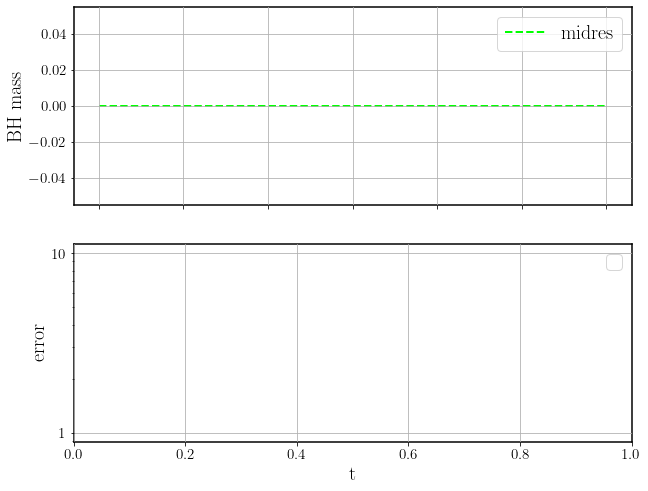

In [13]:
order = 2
fig = plt.figure(figsize=(10,8))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212)

# Track the BH mass, show constant despite gauge evolution
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)
# omega_HR, ah_radius_HR, bh_mass_HR = get_horizon_diagnostics(solution_HR, t, grid_HR, background_HR, my_matter)
# omega_LR, ah_radius_LR, bh_mass_LR = get_horizon_diagnostics(solution_LR, t, grid_LR, background_LR, my_matter)

# ax1.plot(t, bh_mass_LR, 'r', ls="-", label="lowres")
ax1.plot(t, bh_mass, 'lime', ls="--", label="midres")
# ax1.plot(t, bh_mass_HR, 'b', ls=":", label="highres")

# ax2.plot(t, abs(bh_mass_LR-bh_mass), 'r', ls="-", label="lowres-midres")
# ax2.plot(t, abs(bh_mass-bh_mass_HR), 'lime', ls="-", label="midres-highres")
# ax2.plot(t, abs(bh_mass_LR-bh_mass)/2**order, 'k', ls="--", label="2nd order")

ax1.legend(loc='best')
ax2.legend(loc='best')

ax2.set_xlabel('t')
ax1.set_ylabel('BH mass')
ax2.set_ylabel('error')

# ax1.set_xlim([0,40])
# ax2.set_xlim([0,40])

ax2.set_yscale('log')

ax1.set_xticklabels([])
ax1.grid()
ax2.grid()